In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
import mne
from torchdiffeq import odeint_adjoint
import time
import sys
import gc
from scipy.signal import detrend
from scipy.integrate import solve_ivp
import torch.nn.functional as F
from tqdm.notebook import tqdm
from numpy.fft import fft, ifft
from scipy.signal import medfilt
from torchdiffeq import odeint

In [2]:
# extra functions 
def fft(data,sfreq):
    n_samples = data.shape[0]
    fft_vals = np.fft.rfft(data)
    fft_freqs = np.fft.rfftfreq(n_samples, d=1/sfreq)
    fft_amplitude = np.abs(fft_vals)
    return fft_freqs, fft_amplitude

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter(order, [lowcut/(0.5*fs), highcut/(0.5*fs)], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

def get_median_filter_width(sampling_rate, duration):
    res = int( sampling_rate*duration )
    res += ((res%2) - 1) 
    return res

def filter_signal(X):
    global mfa
    X0 = X  
    for mi in range(0,len(mfa)):
        X0 = medfilt(X0,mfa[mi]) # apply median filter one by one on top of each other
    X0 = np.subtract(X,X0)  
    return X0

In [3]:
fs = 100  
total_duration = 15
train_duration = 10
test_duration = 5
t_train = np.arange(0, train_duration, 1/fs)
t_test = np.arange(train_duration, total_duration, 1/fs)
t_full = np.arange(0, total_duration, 1/fs)
fs_hidden = fs
file_new_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
raw = mne.io.read_raw_fif(file_new_raw, preload=False)
data, times = raw[322, 2000:17000]
ecg_data = -data[0]
mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
eeg_data = mat['Value']
eeg_data = eeg_data[:, 2000:17000]
sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
sc_matrix = sc_data["sc"]
max_val = np.max(sc_matrix)
Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix

non_zero_indices_per_row = [np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])]

def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=30):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, detrended)
    normalized = (filtered - np.mean(filtered)) / np.std(filtered)
    return normalized

ecg_detrended = detrend(ecg_data, type='linear')
ecg_data = ecg_detrended

fs,Fs,lowcut,highcut,order = 1000,1000,0.65,40.0,4
filtered_ecg = bandpass_filter(ecg_data, lowcut, highcut, fs, order)

ms_flt_array = [0.2,0.6]    
mfa = np.zeros(len(ms_flt_array), dtype='int')
for i in range(0, len(ms_flt_array)):
    mfa[i] = get_median_filter_width(Fs,ms_flt_array[i])
signal_flt = filter_signal(filtered_ecg)

# step 4 - Normalize the filtered signal to [0, 1]
normalized_ecg_basecorrect = ((signal_flt - np.min(signal_flt)) / (np.max(signal_flt) - np.min(signal_flt))) 
ecg_processed_1k=normalized_ecg_basecorrect
eeg_processed_1k = np.array([preprocess_signal(row, fs=1000, lowcut=1.5, highcut=20) for row in eeg_data])
ecg_processed = ecg_processed_1k[::10]
eeg_processed = eeg_processed_1k[:, ::10]
fs=100

Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.


In [4]:

train_samples = len(t_train)
test_samples = len(t_test)

ecg_train = ecg_processed[:train_samples]
ecg_test = ecg_processed[train_samples:train_samples + test_samples]

eeg_train = eeg_processed[:, :train_samples]
eeg_test = eeg_processed[:, train_samples:train_samples + test_samples]

print(len(ecg_train), len(ecg_test), eeg_train.shape, eeg_test.shape)

1000 500 (68, 1000) (68, 500)


In [5]:

def simulate_coupled_oscillators(T=10, dt=1/1000, alpha=1, omega1=5.01, omega2=5.1, A_init=0.0001, theta_init=3.14, n=1.0, modulation=None):
    N = int(T / dt)
    r1, r2, phi1, phi2 = 1.0, 1.0, 0.0, 0.0
    A12, A21 = A_init, A_init
    theta12, theta21 = theta_init, theta_init

    R1, R2, Phi1, Phi2 = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    for i in range(N):
        R1[i], R2[i], Phi1[i], Phi2[i] = r1, r2, phi1, phi2

        coupling12 = A12 * r2 * np.cos(theta12 + n * (phi2 - phi1))
        coupling21 = A21 * r1 * np.cos(theta21 + n * (phi1 - phi2))

        dr1 = alpha * r1 - r1**3 + coupling12 + (0.1*modulation[i,0] if modulation is not None and i < len(modulation) else 0)
        dr2 = alpha * r2 - r2**3 + coupling21 + (0.1*modulation[i,1] if modulation is not None and i < len(modulation) else 0)

        dphi1 = omega1 + A12 * r2 / r1 * np.sin(theta12 + n * (phi2 - phi1))
        dphi2 = omega2 + A21 * r1 / r2 * np.sin(theta21 + n * (phi1 - phi2))

        r1 += dr1 * dt
        r2 += dr2 * dt
        phi1 += dphi1 * dt
        phi2 += dphi2 * dt

    return np.stack((R1*np.cos(Phi1), R1*np.sin(Phi1), R2*np.cos(Phi2), R2*np.sin(Phi2)), axis=1)

def get_random_frequencies(num_regions, osc_per_region, low=1, high=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    total_oscillators = num_regions * osc_per_region
    freqs_hz = np.random.uniform(low, high, total_oscillators)
    return 2 * np.pi * freqs_hz

def expand_structural_connectivity(Sc_region, osc_per_region, intra_value=0.0001, seed=None):
    if seed is not None:
        np.random.seed(seed)
    num_regions = Sc_region.shape[0]
    N = num_regions * osc_per_region
    Sc_full = np.zeros((N, N))
    for i in range(num_regions):
        for j in range(num_regions):
            start_i, end_i = i * osc_per_region, (i + 1) * osc_per_region
            start_j, end_j = j * osc_per_region, (j + 1) * osc_per_region
            if i == j:
                Sc_full[start_i:end_i, start_j:end_j] = intra_value
            else:
                rand_block = np.random.rand(osc_per_region, osc_per_region)
                rand_block *= Sc_region[i, j] / (rand_block.sum() + 1e-9)
                Sc_full[start_i:end_i, start_j:end_j] = rand_block
    np.fill_diagonal(Sc_full, 0.0)
    return Sc_full

def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

# --- NEURAL NETWORK MODELS ---
class HeartModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=100, feature_dim=50, output_dim=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, feature_dim),
        )
        self.output_layer = nn.Linear(feature_dim, output_dim)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.output_layer(features)

    def get_features(self, x):
        return self.feature_extractor(x)

In [6]:
class OscillatorODEFunc(nn.Module):
    def __init__(self, N_osc, mu, k, omega, C, theta, device="cpu"):
        super().__init__()
        self.N_osc = N_osc
        self.mu = mu # nn.Parameter
        self.k = k   # nn.Parameter

        self.register_buffer("omega", omega) # nn.Parameter from OscillatorLayer
        self.register_buffer("C", C)
        self.register_buffer("theta", theta)

        # Internal clamps for numerical stability
        self.r_min = 0.001
        self.r_max = 2.0
        #self.power_min = 1e-6
        #self.power_max = 2.0
        self.phase_clip = 2*np.pi

        # This will be updated by the OscillatorLayer.forward before calling odeint
        # It should be (B, N_osc, 1) or (1, N_osc, 1) if B=1
        self.input_f = None

    def forward(self, t, state):
        # state is (B, N_osc * 2) -> split into (B, N_osc) for r and phi
        B = state.shape[0]
        N_osc = self.N_osc

        r = state[:, :N_osc].unsqueeze(-1)  # (B, N_osc, 1)
        phi = state[:, N_osc:].unsqueeze(-1) # (B, N_osc, 1)

        # Constant input_f for the entire ODE integration
        input_f = self.input_f # (B, N_osc, 1)

        omega_i = self.omega.unsqueeze(0).unsqueeze(-1) # (1, N_osc, 1)
        omega_j = self.omega.unsqueeze(0).unsqueeze(1) # (1, 1, N_osc)

        #rho = omega_i / (omega_j + 1e-8) # (1, N_osc, N_osc)
        #rho= torch.clamp(rho, 0.1,0.6)
        C = self.C.unsqueeze(0) # (1, N_osc, N_osc)
        theta = self.theta.unsqueeze(0) # (1, N_osc, N_osc)

        phi_i = phi # (B, N_osc, 1)
        phi_j = phi.transpose(1, 2) # (B, 1, N_osc)

        # --- Phase term ---
        phase_term = phi_j/omega_j - phi_i/omega_i + theta/(omega_i*omega_j) # (B, N_osc, N_osc)

        # Clamp large phase excursions (numerical safety)
        phase_term = torch.clamp(
            phase_term,
            -self.phase_clip,
            self.phase_clip
        )

        # --- Power amplitude (Log-Domain Safe) ---
        r_j = r.transpose(1, 2) # (B, 1, N_osc)
        r_j_clamped = torch.clamp(r_j, self.r_min, self.r_max)

        #log_r_j = torch.log(r_j_clamped)
        #r_power = torch.exp(rho * log_r_j) # (B, N_osc, N_osc)

        # Clamp power explosion
        r_safe = torch.clamp(r, self.r_min, self.r_max) # (B, N_osc, 1)
        r= r_safe

        coupling_r = self.k * torch.sum(
            C * r_j * torch.cos(omega_i*(phase_term)),
            dim=-1,
            keepdim=True
        ) # (B, N_osc, 1)



        coupling_phi = self.k * torch.sum(
            C * (r_j/r_safe) * torch.sin(omega_i*(phase_term)),
            dim=-1,
            keepdim=True
        ) # (B, N_osc, 1)

        dr_dt = (self.mu - r**2) * r + coupling_r + input_f # (B, N_osc, 1)
        dphi_dt = self.omega.unsqueeze(0).unsqueeze(-1) + coupling_phi # (B, N_osc, 1)

        return torch.cat([
            dr_dt.squeeze(-1),
            dphi_dt.squeeze(-1)
        ], dim=-1)


class OscillatorLayer(nn.Module):
    def __init__(self, N_osc=16, T=2.0, fs=100, device="cpu",
                 coupling_sparsity=0.3, seed=42):

        super().__init__()

        self.N_osc = N_osc
        self.T = T
        self.fs = fs
        self.dt = 1.0 / fs

        torch.manual_seed(seed)

        freqs = 2.0 + torch.rand(N_osc, device=device) * 8.0

        # Initialize learnable parameters
        self.mu_param = nn.Parameter(torch.tensor(1.0, device=device)) # Mu can be a learnable parameter
        self.k_param = nn.Parameter(torch.tensor(0.01, device=device)) # k can be a learnable parameter
        self.omega_param = nn.Parameter(2 * torch.pi * freqs) # omega is learnable

        # C and theta are structural, so typically not learned, but passed as buffers
        mask = torch.rand(N_osc, N_osc, device=device) > coupling_sparsity
        mask.fill_diagonal_(False)
        C_val = torch.rand(N_osc, N_osc, device=device) * 0.02
        self.C_buffer = C_val * mask.float()

        theta_val = torch.zeros(N_osc, N_osc, device=device)
        theta_val.fill_diagonal_(0.0)
        self.theta_buffer = theta_val

        # Instantiate the ODE function
        self.ode_func = OscillatorODEFunc(
            N_osc=N_osc,
            mu=self.mu_param,
            k=self.k_param,
            omega=self.omega_param,
            C=self.C_buffer,
            theta=self.theta_buffer,
            device=device
        )

        # Initial conditions for the ODE solver, registered as buffers
        self.register_buffer("initial_r", torch.ones(N_osc, device=device) * 0.1)
        self.register_buffer("initial_phi", torch.zeros(N_osc, device=device))

        # Stability clamps, as in original loop for final output
        self.r_min = 0.01
        self.r_max = 2.0

    def forward(self, input_features):
        # input_features: (B, N_osc) from ECGToOscillatorMLP.pre_osc
        B = input_features.shape[0]

        # Convert input_features to (B, N_osc, 1) for consistency in ODEFuc
        self.ode_func.input_f = input_features.unsqueeze(-1)

        # Prepare initial state y0 = [r, phi] for all batches
        initial_r_batch = self.initial_r.unsqueeze(0).repeat(B, 1) # (B, N_osc)
        initial_phi_batch = self.initial_phi.unsqueeze(0).repeat(B, 1) # (B, N_osc)
        y0 = torch.cat([initial_r_batch, initial_phi_batch], dim=-1) # (B, N_osc * 2)

        # Generate time steps
        t_eval = torch.arange(0, self.T, self.dt, device=input_features.device, dtype=torch.float32)

        # Solve the ODE using odeint (not odeint_adjoint to allow gradients to flow)
        sol = odeint(
            self.ode_func,
            y0,
            t_eval,
            method="rk4" # Use the same method as TorchRevHopfNetwork
        ) # sol shape: (T_steps, B, N_osc * 2)

        # Extract final r and phi (last time step)
        r_final = sol[-1, :, :self.N_osc] # (B, N_osc)
        phi_final = sol[-1, :, self.N_osc:] # (B, N_osc)

        # Apply final amplitude clamp as in original loop
        r_final = torch.clamp(r_final, self.r_min, self.r_max)

        return torch.cat([
            r_final * torch.cos(phi_final),
            #r_final * torch.sin(phi_final)
        ], dim=-1)




In [7]:


class ECGToOscillatorMLP(nn.Module):
    """ECG → MLP → OscillatorLayer → MLP → Brain drive [N]"""
    def __init__(self, ecg_dim=50, N_VNS=16, hidden_dim=64, output_dim=16, device="cuda"):
        super().__init__()
        self.pre_osc = nn.Sequential(
            nn.Linear(ecg_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, N_VNS)
        )
        self.osc_layer = OscillatorLayer(N_osc=N_VNS, device=device, coupling_sparsity=0.3, seed=42)
        self.post_osc = nn.Sequential(
            nn.Linear(N_VNS * 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, ecg_features):  # [batch, ecg_dim] or [ecg_dim]
        if ecg_features.dim() == 1:
            ecg_features = ecg_features.unsqueeze(0)  # (1, ecg_dim)

        ecg_features = (
            ecg_features - ecg_features.mean(dim=-1, keepdim=True)
        ) / (ecg_features.std(dim=-1, keepdim=True) + 1e-6)

        pre = self.pre_osc(ecg_features)
        osc_hidden = self.osc_layer(pre)
        combined = torch.cat([osc_hidden], dim=-1)
        brain_drive = self.post_osc(combined)

        if brain_drive.shape[0] == 1:
            return brain_drive.squeeze(0)  # (output_dim,)
        return brain_drive

In [8]:
class ODEFuc(nn.Module):
    def __init__(self, mu, eta_theta, eta_omega, eta_alpha,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100):

        super().__init__()
        self.mu = mu
        self.eta_theta = eta_theta
        self.eta_omega = eta_omega
        self.eta_alpha = eta_alpha
        self.D_function = D_function
        self.N = N
        self.fs = fs

        self.register_buffer(
            'Sc',
            torch.tensor(Sc, dtype=torch.float32)
        )

        # brain_drive_full is stored as a plain attribute (NOT a buffer) so that
        # when using standard odeint, the full autograd graph is preserved and
        # gradients flow back through it to ecg_to_osc_mlp.
        self.brain_drive_full = brain_drive_full

    def forward(self, t, state):

        N = self.N

        r = state[:N]
        phi = state[N:2*N]
        theta = state[2*N:2*N + N**2].view(N, N)
        omega = state[2*N + N**2:3*N + N**2]
        alpha = state[3*N + N**2:4*N + N**2]

        omega_safe = torch.clamp(omega, 2 * np.pi * 0.5, 2 * np.pi * 20)
        r = torch.clamp(r, 1e-1, 2.0)
        alpha = torch.clamp(alpha, -1.0, 1.0)
        r_safe = torch.clamp(torch.where(r < 1e-6, torch.tensor(1e-6, device=r.device, dtype=r.dtype), r), 1e-5, 10.0)  # Higher min for stability
        r = r_safe

        # --- Correct Phase Difference for Power Coupling ---
        #phase_diff = (
        #    omega_ratio * phi[None, :]  ## Use Phi/omega- Phi/omega +theta/(omega1*omega2)
        #    - phi[:, None]
        #    + theta
        #)
        ## reviseed phase dofference..
        # Phase differences matrix
        phase_diff = torch.clamp(
            phi[None, :] / omega_safe[None, :] -
            phi[:, None] / omega_safe[:, None] +
            theta / (omega_safe[:, None] * omega_safe[None, :]), -1e2, 1e2)  # Added clamp to prevent extreme phases


        # ----- Target forcing -----
        D = torch.tensor(
            self.D_function(t.item()),
            device=state.device,
            dtype=state.dtype
        )

        P = torch.sum(alpha * r * torch.cos(phi))
        e = D - P

        # ----- Precomputed brain drive indexing -----
        if self.brain_drive_full is not None:
            t_idx = min(
                round(t.item() * self.fs),
                self.brain_drive_full.shape[0] - 1
            )
            ecg_input = self.brain_drive_full[t_idx]
        else:
            ecg_input = torch.zeros(N, device=state.device)

        coupling_r = torch.sum(torch.abs(self.Sc) * r[None, :] * torch.cos(phase_diff), dim=1)

        drdt = (self.mu - r**2) * r \
               + coupling_r \
               + e * torch.cos(phi) \
               + ecg_input

        coupling_phi = torch.sum(torch.abs(self.Sc) * (r[None, :] / r_safe[:, None]) * torch.sin(phase_diff), dim=1)
        dphidt = omega + coupling_phi - (e / r_safe) * torch.sin(phi)

         # Adaptive dynamics (these are "frozen" by setting etas to 0 in Stage 2)
        dthetadt = self.eta_theta * torch.sin(phase_diff) * torch.abs(self.Sc)
        domegadt = -self.eta_omega * e * torch.sin(phi)
        dalphadt = self.eta_alpha * e * r * torch.cos(phi)

        # Clamp gradients to prevent explosions

        ## Put a clamp  on drdt, domegadt to restrict the bound..
        return torch.cat([
            drdt.flatten(),
            dphidt.flatten(),
            dthetadt.flatten(),
            domegadt.flatten(),
            dalphadt.flatten()
        ])


class TorchRevHopfNetwork:
    def __init__(self, mu, eta_omega, eta_alpha, eta_theta,
                 D_function, N, Sc,
                 brain_drive_full=None,
                 fs=100,
                 device="cuda"):

        self.device = torch.device(device)
        self.N = N

        self.ode_func = ODEFuc(
            mu=mu,
            eta_theta=eta_theta,
            eta_omega=eta_omega,
            eta_alpha=eta_alpha,
            D_function=D_function,
            N=N,
            Sc=Sc,
            brain_drive_full=brain_drive_full,
            fs=fs
        ).to(self.device)

    def solve(self, r0, phi0, theta0, omega0, alpha0, t_eval, use_adjoint=True):
        # use_adjoint=True  → odeint_adjoint (memory-efficient, for no-grad stages)
        # use_adjoint=False → odeint (standard autograd graph, required when
        #                    brain_drive_full must carry gradients back to ecg_to_osc_mlp)

        y0 = torch.tensor(
            np.concatenate([r0, phi0, theta0.flatten(), omega0, alpha0]),
            device=self.device,
            dtype=torch.float32
        )

        t_eval_tensor = torch.tensor(
            t_eval,
            device=self.device,
            dtype=torch.float32
        )

        if use_adjoint:
            sol = odeint_adjoint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )
        else:
            # Standard odeint builds a full autograd graph so gradients flow
            # back through brain_drive_full to ecg_to_osc_mlp parameters.
            sol = odeint(
                self.ode_func,
                y0,
                t_eval_tensor,
                method="rk4"
            )

        N = self.N

        r = sol[:, :N]
        phi = sol[:, N:2*N]
        theta = sol[:, 2*N:2*N + N**2].view(-1, N, N)
        omega = sol[:, 2*N + N**2:3*N + N**2]
        alpha = sol[:, 3*N + N**2:4*N + N**2]

        rcos_phi = torch.sum(r * torch.cos(phi), dim=1)

        return r, phi, theta, omega, alpha, rcos_phi



In [9]:
def train_feedback_loop(trained_heart_model, trained_mlp_model, ecg_target_signal, T, dt, device, num_epochs=70000, loop_iterations=1):
    print("--- Starting Feedback Loop Training ---")

    trained_heart_model.apply(reset_weights)
    trained_heart_model.train()
    feedback_mlp = FeedbackMLP(input_dim=trained_mlp_model.net[-1].out_features).to(device)
    optimizer = optim.Adam(list(trained_heart_model.parameters()) + list(feedback_mlp.parameters()), lr=1e-3)
    criterion = nn.MSELoss()

    num_samples = int(np.round(T / dt))
    time_axis = np.linspace(0, T, num_samples, endpoint=False)
    ecg_interp = interp1d(np.linspace(0, T, len(ecg_target_signal), endpoint=False), ecg_target_signal,
                          kind='linear', bounds_error=False, fill_value="extrapolate")
    ecg_target_resampled = torch.tensor(ecg_interp(time_axis), dtype=torch.float32, device=device).unsqueeze(1)

    for epoch in range(num_epochs):
        sim_osc = simulate_coupled_oscillators(T=T, dt=dt)
        sim_osc_tensor = torch.tensor(sim_osc, dtype=torch.float32, device=device)

        for _ in range(loop_iterations):
            hidden_repr = trained_heart_model.get_features(sim_osc_tensor)
            mlp_output = trained_mlp_model(hidden_repr)
            feedback_output = feedback_mlp(mlp_output)
            feedback_np = feedback_output.detach().cpu().numpy()

            sim_osc = simulate_coupled_oscillators(T=T, dt=dt, modulation=feedback_np)
            sim_osc_tensor = torch.tensor(sim_osc, dtype=torch.float32, device=device)

        predicted_ecg = trained_heart_model(sim_osc_tensor)
        loss = criterion(predicted_ecg, ecg_target_resampled)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"Feedback Loop Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

    print("--- Feedback Loop Training Finished ---")
    return trained_heart_model, feedback_mlp


In [10]:
def train_heart_model(ecg_target_signal,t_duration_train,fs,device):
    print("--- Starting Heart Model Pre-training ---")
    heart_model = HeartModel().to(device)
    optimizer = optim.Adam(heart_model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1000)
    criterion = nn.MSELoss()

    sim_osc_input = torch.tensor(simulate_coupled_oscillators(T=t_duration_train, dt=1/fs), dtype=torch.float32).to(device)
    ecg_target = torch.tensor(ecg_target_signal, dtype=torch.float32).to(device).unsqueeze(1)

    # FIX 4 (support): collect loss history so we can plot it later
    heart_losses = []

    for epoch in range(25000):
        predicted_ecg = heart_model(sim_osc_input)
        loss = criterion(predicted_ecg, ecg_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(loss.item())
        heart_losses.append(loss.item())
        if (epoch + 1) % 2500 == 0:
            print(f"Heart Epoch {epoch+1}, Loss: {loss.item():.6f}")
    print("--- Heart Pre-training Finished ---")
    return heart_model, heart_losses


def pre_train_brain_model(eeg_processed, Sw_all, target_idx, non_zero_indices_per_row, t, D_function, device):
    print("\n--- Stage 1: Brain Pre-training ---")
    connected_indices = np.unique(np.append(non_zero_indices_per_row[target_idx], target_idx))
    N_reduced_regions = len(connected_indices)
    osc_per_region = 3
    N = N_reduced_regions * osc_per_region

    Sc_reduced_regional = Sw_all[np.ix_(connected_indices, connected_indices)]
    Sc_reduced_osc = expand_structural_connectivity(Sc_reduced_regional, osc_per_region, seed=42)

    omega_full = get_random_frequencies(68, osc_per_region, low=1, high=20, seed=42)
    alpha_full = np.random.uniform(0.1, 0.7, 68 * osc_per_region)
    omega0 = np.concatenate([omega_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices])
    alpha0 = np.clip(np.concatenate([alpha_full[i * osc_per_region:(i + 1) * osc_per_region] for i in connected_indices]), 0.05, 0.5)
    r0 = 0.1 * np.ones(N)

    phi0 = np.zeros(N)
    theta_random = np.pi * (2 * np.random.rand(N, N) - 1)
    theta0 = theta_random - theta_random.T

    model = TorchRevHopfNetwork(
        mu=1.0, eta_omega=0.05, eta_alpha=0.005, eta_theta=0.05,
        D_function=D_function, N=N, Sc=Sc_reduced_osc,
        device=device
    )

    criterion = nn.MSELoss()
    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    for epoch in range(100):
        with torch.no_grad():
            # use_adjoint=True is fine here since we don't need gradients
            r, phi, theta, omega, alpha, _ = model.solve(r0, phi0, theta0, omega0, alpha0, t, use_adjoint=False)
            P_out = torch.sum(alpha * r * torch.cos(phi), axis=1)
            loss = criterion(P_out, D_true)
            losses.append(loss.item())

            theta0, omega0 = theta[-1].cpu().numpy(), omega[-1].cpu().numpy()
            alpha0 = alpha[-1].cpu().numpy()

        if (epoch + 1) % 10 == 0:
            print(f"Brain Epoch {epoch+1}/30, Loss: {loss.item():.6f}")

        torch.cuda.empty_cache()
        gc.collect()

    final_params = {
        'r': 0.1 * np.ones(N),
        'phi': np.zeros(N),
        'theta': theta[-1].cpu().numpy(),
        'omega': omega[-1].cpu().numpy(),
        'alpha': alpha[-1].cpu().numpy()
    }
    return final_params, Sc_reduced_osc, N, losses


def train_mlp_on_frozen_brain(
        trained_heart_model,
        initial_brain_params,
        Sc_reduced_osc,
        N,
        D_function,
        t, t_duration_train,fs,
        device):

    print("\n--- Stage 2: ECG → OscillatorLayer → Brain Training ---")

    ecg_to_osc_mlp = ECGToOscillatorMLP(
        ecg_dim=50,
        N_VNS=18,
        hidden_dim=64,
        output_dim=N,
        device=device
    ).to(device)

    # FIX 8a: Lower LR from 1e-2 → 1e-3 to prevent divergence.
    # With standard odeint, gradients backprop through 200 ODE steps and can be
    # very large. A high LR causes the optimizer to overshoot → loss explodes.
    optimizer = torch.optim.Adam(
        ecg_to_osc_mlp.parameters(),
        lr=5e-3
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=10,
        threshold=1e-3,
        cooldown=5,
        min_lr=1e-5
    )

    criterion = nn.MSELoss()

    # -------- Extract ECG features (frozen heart model) --------
    with torch.no_grad():
        sim_input = torch.tensor(
            simulate_coupled_oscillators(T=t_duration_train, dt=0.01),
            dtype=torch.float32
        ).to(device)
        hidden_repr = trained_heart_model.get_features(sim_input)  # (T_steps, feature_dim)

    D_true = torch.tensor(D_function(t), device=device, dtype=torch.float32)
    losses = []

    model = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=None,
        fs=100,
        device=device
    )

    for epoch in range(200):

        raw_drive = ecg_to_osc_mlp(hidden_repr)  # (T_steps, N) — has grad_fn

        # FIX 8b: Scale and bound the brain drive with tanh * 0.1.
        # Without this, the MLP output is unbounded and can inject very large
        # values into drdt, destabilizing the ODE and causing loss to explode.
        brain_drive_full = (raw_drive)

        # Update brain_drive_full on the ODE func each epoch.
        # Stored as a plain attribute (not a buffer) so the autograd graph is preserved.
        model.ode_func.brain_drive_full = brain_drive_full

        # FIX 7 (CRITICAL): use_adjoint=False → standard odeint builds a full autograd
        # graph so gradients flow back through brain_drive_full to ecg_to_osc_mlp.
        # odeint_adjoint only tracks gradients through registered nn.Module parameters
        # and would raise: "element 0 of tensors does not require grad and does not have a grad_fn"
        r, phi, theta, omega, alpha, _ = model.solve(
            initial_brain_params['r'],
            initial_brain_params['phi'],
            initial_brain_params['theta'],
            initial_brain_params['omega'],
            initial_brain_params['alpha'],
            t,
            use_adjoint=False
        )

        P_out = torch.sum(alpha * r * torch.cos(phi), dim=1)

        mse_loss = criterion(P_out, D_true)

        loss = mse_loss

        settle = int(0.1 * model.ode_func.fs)   # ignore first 300 ms

        loss = (
            criterion(P_out[settle:], D_true[settle:])

        )
        optimizer.zero_grad()
        loss.backward()
        # FIX 8a (cont.): Gradient clipping prevents exploding gradients from the
        # deep ODE unroll (200 steps of backprop through Euler integration).
        torch.nn.utils.clip_grad_norm_(ecg_to_osc_mlp.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step(loss.item())

        losses.append(loss.item())

        if (epoch + 1) % 20 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch {epoch+1}, "
                f"Loss: {loss.item():.6f}, "
                f"LR: {current_lr:.3e}"
            )

        # FIX 3: Free GPU memory each epoch
        torch.cuda.empty_cache()
        gc.collect()

    return ecg_to_osc_mlp, losses

In [11]:
class FeedbackMLP(nn.Module):
    def __init__(self, input_dim=16, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, mlp_output):
        return self.net(mlp_output)

In [12]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"--- Using device: {device} ---")
target_idx = 0
target_signal_train = eeg_train[target_idx]
target_signal_full = eeg_processed[target_idx] 
D_function = interp1d(t_train, target_signal_train, kind='linear', bounds_error=False, fill_value=0.0)


--- Using device: cuda ---


In [13]:

trained_heart_model,heart_losses = train_heart_model(ecg_train, train_duration, fs, device)
with torch.no_grad():
    simulated_ecg_input=torch.tensor(simulate_coupled_oscillators(T=train_duration, dt=1/fs), dtype=torch.float32).to(device)
    hidden_repr=trained_heart_model.get_features(simulated_ecg_input)

final_brain_params, Sc_reduced_osc, N, brain_losses = pre_train_brain_model(
    eeg_train, Sw_all, target_idx, non_zero_indices_per_row, t_train, D_function, device
)


--- Starting Heart Model Pre-training ---
Heart Epoch 2500, Loss: 0.012648
Heart Epoch 5000, Loss: 0.012101
Heart Epoch 7500, Loss: 0.011576
Heart Epoch 10000, Loss: 0.011086
Heart Epoch 12500, Loss: 0.010623
Heart Epoch 15000, Loss: 0.010304
Heart Epoch 17500, Loss: 0.010014
Heart Epoch 20000, Loss: 0.009706
Heart Epoch 22500, Loss: 0.010791
Heart Epoch 25000, Loss: 0.009037
--- Heart Pre-training Finished ---

--- Stage 1: Brain Pre-training ---
Brain Epoch 10/30, Loss: 0.998211
Brain Epoch 20/30, Loss: 0.823573
Brain Epoch 30/30, Loss: 0.669117
Brain Epoch 40/30, Loss: 0.574993
Brain Epoch 50/30, Loss: 0.514199
Brain Epoch 60/30, Loss: 0.474048
Brain Epoch 70/30, Loss: 0.442461
Brain Epoch 80/30, Loss: 0.422214
Brain Epoch 90/30, Loss: 0.408574
Brain Epoch 100/30, Loss: 0.379710


In [ ]:


trained_mlp_model, mlp_losses = train_mlp_on_frozen_brain(
    trained_heart_model, final_brain_params, Sc_reduced_osc, N, D_function, t_train, train_duration, fs, device
)



--- Stage 2: ECG → OscillatorLayer → Brain Training ---


OutOfMemoryError: CUDA out of memory. Tried to allocate 28.00 MiB. GPU 0 has a total capacity of 7.69 GiB of which 24.75 MiB is free. Including non-PyTorch memory, this process has 7.35 GiB memory in use. Of the allocated memory 7.18 GiB is allocated by PyTorch, and 4.27 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 


--- Generating final predictions for train and test sets ---


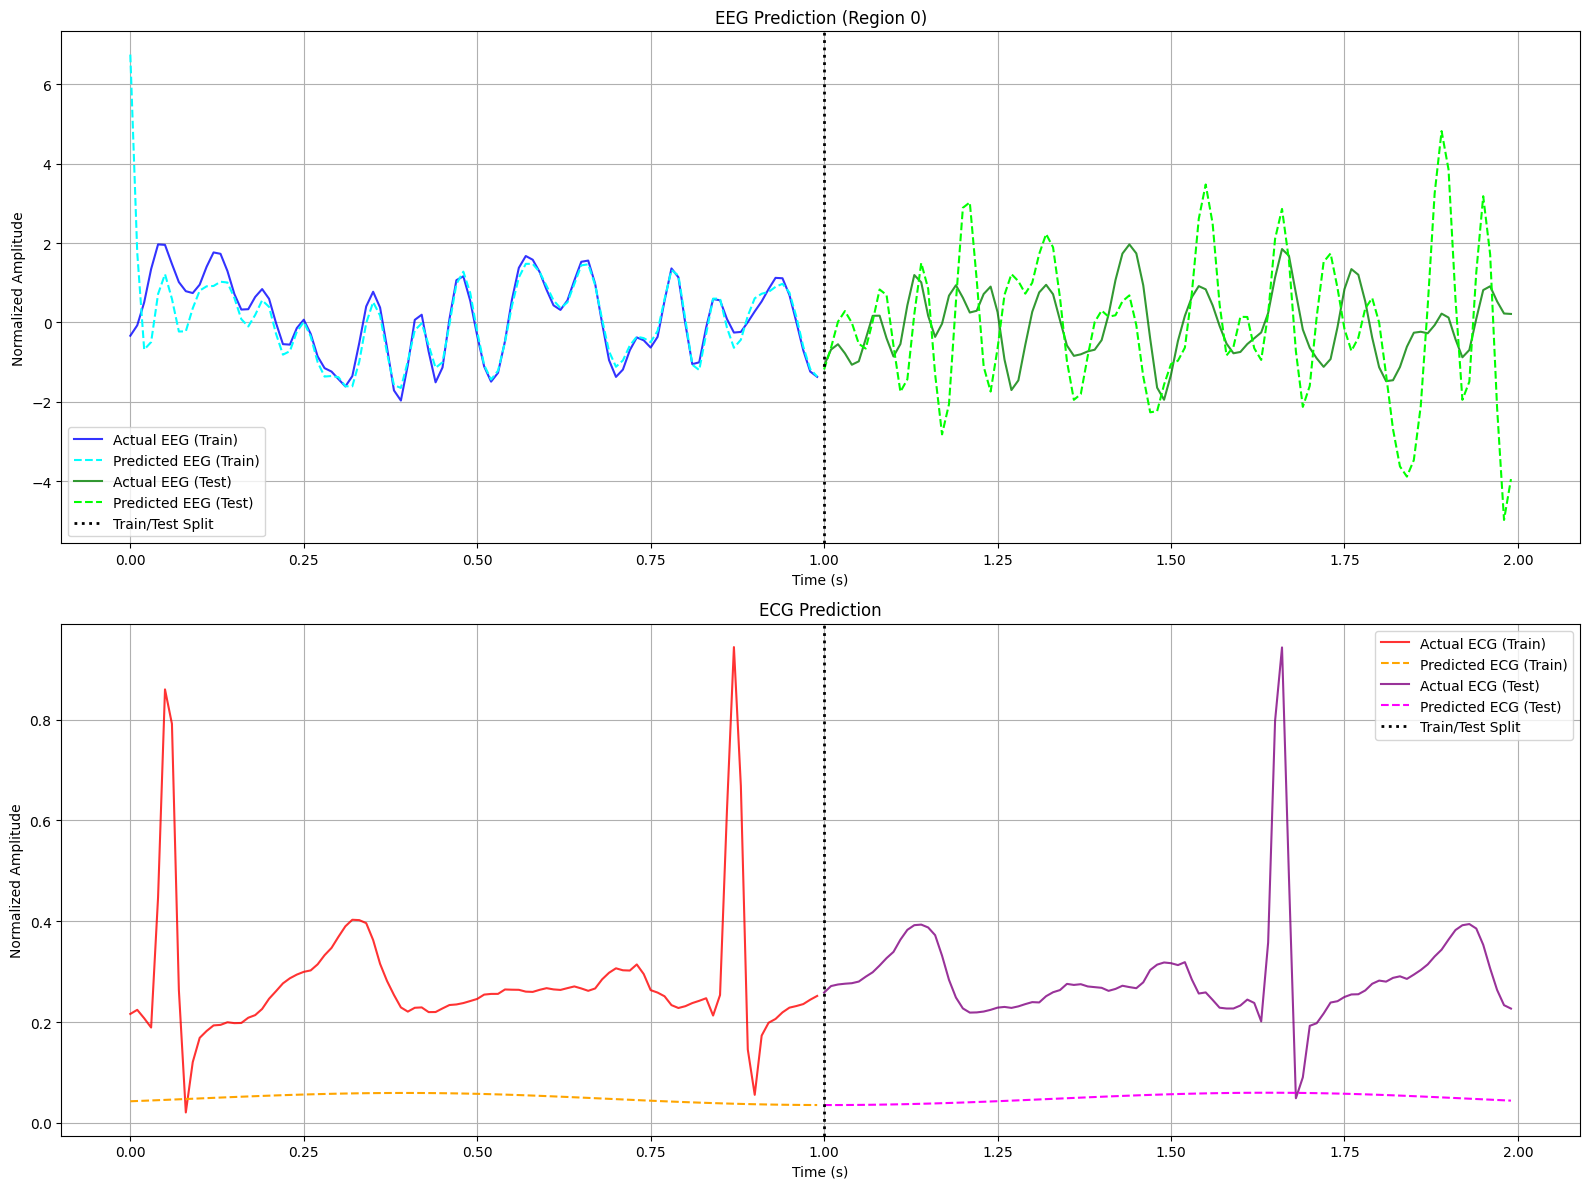

In [ ]:


# ---- Final prediction on FULL dataset (train + test) ----
print("\n--- Generating final predictions for train and test sets ---")
trained_heart_model.eval()
trained_mlp_model.eval()

with torch.no_grad():
    r0, phi0, theta0, omega0, alpha0 = (
        final_brain_params['r'], final_brain_params['phi'],
        final_brain_params['theta'], final_brain_params['omega'],
        final_brain_params['alpha']
    )


    sim_osc_final = simulate_coupled_oscillators(T=total_duration, dt=1/fs)
    sim_osc_tensor = torch.tensor(sim_osc_final, dtype=torch.float32, device=device)
    hidden_repr_final = trained_heart_model.get_features(sim_osc_tensor)

    predicted_ecg_final = trained_heart_model(sim_osc_tensor).detach().cpu().numpy().flatten()
    D_function_full = interp1d(t_full, target_signal_full, kind='linear', bounds_error=False, fill_value=0.0)
    brain_drive_full = trained_mlp_model(hidden_repr_final)

    model_final = TorchRevHopfNetwork(
        mu=1.0,
        eta_omega=0.0,
        eta_alpha=0.0,
        eta_theta=0.0,
        D_function=D_function_full,
        N=N,
        Sc=Sc_reduced_osc,
        brain_drive_full=brain_drive_full,
        fs=fs,
        device=device
    )

    r, phi, theta, omega, alpha,rcosphi = model_final.solve(r0, phi0, theta0, omega0, alpha0, t_full)
    P_out_final = torch.sum(alpha * r * torch.cos(phi), axis=1).detach().cpu().numpy()

# Split predictions into train and test sets for plotting
pred_ecg_train = predicted_ecg_final[:train_samples]
pred_ecg_test = predicted_ecg_final[train_samples:]

pred_eeg_train = P_out_final[:train_samples]
pred_eeg_test = P_out_final[train_samples:]

# --- Plotting ---
plt.figure(figsize=(16, 12))

# Plot EEG results
ax1 = plt.subplot(2, 1, 1)
ax1.plot(t_train, target_signal_train, label='Actual EEG (Train)', color='blue', alpha=0.8)
ax1.plot(t_train, pred_eeg_train, label='Predicted EEG (Train)', color='cyan', linestyle='--')
ax1.plot(t_test, eeg_test[target_idx], label='Actual EEG (Test)', color='green', alpha=0.8)
ax1.plot(t_test, pred_eeg_test, label='Predicted EEG (Test)', color='lime', linestyle='--')
ax1.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
ax1.set_title(f'EEG Prediction (Region {target_idx})')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Normalized Amplitude')
ax1.legend()
ax1.grid(True)

# Plot ECG results
ax2 = plt.subplot(2, 1, 2)
ax2.plot(t_train, ecg_train, label='Actual ECG (Train)', color='red', alpha=0.8)
ax2.plot(t_train, pred_ecg_train, label='Predicted ECG (Train)', color='orange', linestyle='--')
ax2.plot(t_test, ecg_test, label='Actual ECG (Test)', color='purple', alpha=0.8)
ax2.plot(t_test, pred_ecg_test, label='Predicted ECG (Test)', color='magenta', linestyle='--')
ax2.axvline(x=train_duration, color='k', linestyle=':', linewidth=2, label='Train/Test Split')
ax2.set_title('ECG Prediction')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Normalized Amplitude')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Save final predictions if needed
np.save("P_out_final_1.npy", P_out_final)
np.save("predicted_ecg_final_1.npy", predicted_ecg_final)